## <center>CITS5508: Assignment 1</center>

**Student name: Ankit Narula**<br>
**Student ID: 24291627**<br>

## Part 1 : Softmax Regression<br>
### Introduction<br>

Softmax regression (or multinomial logistic regression) is a generalization of logistic regression to the case where we want to handle multiple classes in the target column. In binary logistic regression, the labels were binary, that is for ith observation, $y_i$ ∈{0,1} $y_i$ ∈{0,1}. In the Binary Logistic regression, we used the sigmoid function for the same task. The softmax function is nothing but a generalization of the sigmoid function. Now, this softmax function computes the probability that the ith training sample belongs to class j given the logits vector $Z_i$ as: 
<centre>$$P(y=j \mid Z_i) = [S(Z_i)]_j = \frac{e^{Z_{ij}}}{\sum_{k=1}^{K} e^{Z_{ik}}}$$<centre><br>
In vector form, we can simply write:
<centre>$$P(y=j \mid Z_i) = [S(Z_i)]_j = \frac{e^{Z_{ij}}}{\sum_{k=1}^{K} e^{Z_{ik}}}$$<centre>
​
       

For simplicity, let $S_i$ denote the softmax probability vector for ith observation.

#### Libraries used

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

%matplotlib inline
plt.rcParams['font.size'] = '12'

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score, f1_score
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV


#### 1. Loading the MNSIT dataset from OpenML using scikit-learn

In [2]:
from sklearn.datasets import fetch_openml
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)


#### 2. Displaying some examples from the dataset. Describing what the features and labels represent

In [3]:
# Checking the shape of the dataset of X and y
print(X.shape)
print(y.shape)
X[0],y[0]
#y[0]

(70000, 784)
(70000,)


(array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
        126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,  30,  36

We can see that when we are checking the shapes of X variable, we have a 70000 images and each image has 784 features which represent that image. Each image is 28 x 28 pixels and each feature represents one pixel's intensity from 0 which is white in colour to 255 which is black.
For the Y variable we can see that it has 70000 labels where each label corresponds to 1 image.

#### 3. Spliting the dataset into 70 % training, 15 % validation and 15 % for testing
We cannot directly split the dataset into 3 different parts so we have to do them in stages. Stage 1 would be to split the dataset into 70% training and 30% as a temporary test set. Stage 2 will be to divide the temporary test set into a 50% split. Stage 3 is when we conver the str data type for y to a numoy int data type to prevent mismatch when we come to the prediction stage of the code. We also scale the inputs (X) so that we standardise the pexel values between 0 and 1 so that the model can be stable and efficient.

In [4]:
from sklearn.model_selection import train_test_split

# Step 1: 70% train, 30% test
X_train_main,X_temp,y_train_main,y_temp  = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

# Step 2: split the  test from 30% into 15% val and 15% test
X_val,X_test,y_val,y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

#  Step 3: Converting the str type to a numpy int
y_train_main = y_train_main.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

# Step 4: Scaling the datasets and normalise the data into 0 - 1
X_train = X_train_main / 255.0
X_val   = X_val / 255.0
X_test  = X_test / 255.0

(a) Displaying the class distribution in the training, validation and test sets.

In [5]:
# Checking the training class distribution 
print("Training distribution:")
print(pd.Series(y_train_main).value_counts())

# Checking the validation set class distribution 
print("\nValidation distribution:")
print(pd.Series(y_val).value_counts())

# Checking the test set class distribution
print("\nTest distribution:")
print(pd.Series(y_test).value_counts())

Training distribution:
1    5514
7    5105
3    4999
2    4893
9    4871
0    4832
6    4813
8    4777
4    4777
5    4419
Name: count, dtype: int64

Validation distribution:
1    1182
7    1094
3    1071
2    1048
9    1044
0    1036
6    1031
8    1024
4    1023
5     947
Name: count, dtype: int64

Test distribution:
1    1181
7    1094
3    1071
2    1049
9    1043
0    1035
6    1032
4    1024
8    1024
5     947
Name: count, dtype: int64


(b) Do you need to stratify your split? Why or why not?

Yes, we need Stratified sampling as it is a sampling technique used in statistics and machine learning to ensure that the distribution of samples across different classes or categories remains representative of the population. This is done by dividing the population into distinct groups based on certain characteristics such as classes in our case and then samples are randomly selected from each group in proportion to their representation in the population. This helps to ensure that each class is represented in the sample, making the sample more representative of the entire population and reducing the potential for bias in the analysis process.

#### 4. Implementing a softmax regression with gradient descent using vectorised NumPy code. Implement early stopping based on the validation set.<br>
We will use some helper functions to make it easier to define the softmax function, one hot encoding y.

In [6]:
# defining the softmax function

def softmax(logits):
    exps = np.exp(logits)
    exp_sums = exps.sum(axis=1, keepdims=True)
    return exps / exp_sums

# Defining the one hot coding for y
def one_hot(y, num_classes):
    y = y.astype(int)
    one_hot = np.zeros((y.shape[0], num_classes))
    one_hot[np.arange(y.shape[0]), y] = 1
    return one_hot

- One hot encoding the target variable $y$ i.e. the labels 0–9, is a standard procedure that transforms a single scalar integer into a probability friendly vector. We need to do this to be able to calcualte the difference between what the model predicted and what the actual answer is. <br><br>
- Cross-Entropy Loss also called Log Loss is the standard cost function used to measure how well a classification model is performing. It calculates the difference between two probability distributions, the true labels and the predicted probabilities $\hat{y}$ from the Softmax function.<br><br>
- We are defining the training function of our softmax model below. We are  defining the learning rate (lr) as 0.1, which means that how fast a model should adapt to changing data. If the rate is set high, then the system will rapidly adapt to the new data but it will also tend to quicly forget the old data. If the rate is set low, then the system will have more inertia i.e. it will learn more slowly and be less sensitive to noise of the new data or outliers.

In [ ]:
def train_softmax(X_train, y_train, X_val, y_val, 
                  lr=0.1, epochs=1000, patience=5):

    n_samples, n_features = X_train.shape
    n_classes = 10  
    epislon = 1e-5

    # Initialise weights and bias
    W = np.zeros((n_features, n_classes))
    b = np.zeros((1, n_classes))

    # One-hot encode labels
    y_train_oh = one_hot(y_train, n_classes)
    y_val_oh = one_hot(y_val, n_classes)

    # Track losses
    train_losses = []
    val_losses = []

    best_val_loss = np.inf
    patience_counter = 0
    best_W = W.copy()
    best_b = b.copy()

    for epoch in range(epochs):
        logits = X_train @ W + b
        probs = softmax(logits)

    # Cross Entropy Loss
        m = n_samples
        train_loss = -np.sum(y_train_oh * np.log(probs + epislon)) / m

        train_losses.append(train_loss)

        # Gradients
        grad_W = (X_train.T @ (probs - y_train_oh)) / m
        grad_b = np.sum(probs - y_train_oh, axis=0, keepdims=True) / m

        # Update the weights and bias terms
        W -= lr * grad_W
        b -= lr * grad_b

        # Validation loss 
        val_logits = X_val @ W + b
        val_probs = softmax(val_logits)

        m_val = y_val_oh.shape[0]
        val_loss = -np.sum(y_val_oh * np.log(val_probs + 1e-9)) / m_val

        val_losses.append(val_loss)

        # Early stopping logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_W = W.copy()
            best_b = b.copy()
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 50 == 0:
            print(f"Epoch {epoch}: "
            f"Train Loss={train_loss:.4f}, "
            f"Val Loss={val_loss:.4f} "
            )

        if patience_counter >= patience:
            print("Early stopping triggered:",epoch, train_losses , val_losses)
            break
    return best_W, best_b, train_losses, val_losses
            

- The function train_softmax trains a multiclass softmax regression model using gradient descent with early stopping. It begins by initialising the weight matrix W and bias term b and converts the training and validation labels into one-hot encoded form.<br>

- In each epoch, the model computes logits using a linear transformation and applies the softmax function to obtain class probabilities. The training loss is calculated using cross entropy and stored for tracking. Gradients of the loss are then computed and used to update the weights and biases.<br>

- The model is evaluated on the validation set each epoch by computing the validation loss. If this loss improves, the current parameters are saved as the best otherwise, the patience counter increases. Training stops early when no improvement is seen for a specified number of epochs.<br>

- Finally, the function returns the best weights and bias along with the recorded training and validation losses.<br>

### 
- Prediction function

In [ ]:
def predict(X, W, b):
    logits = X @ W + b
    probs = softmax(logits)
    return np.argmax(probs, axis=1)

- The function above is used to generate the class predictions from the training of the softmax model. It takes the input data (x), with the weights (W) and bias (b). It computes the logits by doing a linear transformation to the input features (X @ W +b).<br><br>
- Then these logits are pushed through the softmax function defined earlier to get the probability distributions of all classes for each sample. Then the function selects the class with the highest probability for each sample using the numpy argmax and gives us the predicted class labels.<br>


- Accuracy function

In [ ]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

- The function above takes the true label and the predicted labels after the model has been trained. It compares each predicted value to the corresponding true label and returns a proportion of correct predictions by calculating the mean of the results and gives us an accuracy score. 

- Training the model

In [10]:
W, b, train_losses, val_losses = train_softmax(
    X_train, y_train_main, X_val, y_val,
    lr=0.1, epochs=600, patience=1
)

Epoch 0: Train Loss=2.3025, Val Loss=2.1968 
Epoch 50: Train Loss=0.7906, Val Loss=0.7929 
Epoch 100: Train Loss=0.6036, Val Loss=0.6117 
Epoch 150: Train Loss=0.5275, Val Loss=0.5374 
Epoch 200: Train Loss=0.4843, Val Loss=0.4954 
Epoch 250: Train Loss=0.4559, Val Loss=0.4677 
Epoch 300: Train Loss=0.4353, Val Loss=0.4478 
Epoch 350: Train Loss=0.4196, Val Loss=0.4326 
Epoch 400: Train Loss=0.4071, Val Loss=0.4206 
Epoch 450: Train Loss=0.3968, Val Loss=0.4108 
Epoch 500: Train Loss=0.3881, Val Loss=0.4026 
Epoch 550: Train Loss=0.3807, Val Loss=0.3956 


The code above starts the actual training of the model using softmax regression. It passes the training data and the validation data. Hyperparameters such as learning rate of 0.1, number of epochs as 300 and a patience of 1 for early stopping. The early stopping is a mechanism that will stop training if the validation loss does not imporve after 1 epoch. The model will learn the optimum weights and bias and minimise the training loss.

- Evaluation on test set

In [11]:
y_pred = predict(X_test, W, b)
print("Test Accuracy:", accuracy(y_test, y_pred))

Test Accuracy: 0.896


The code above evaluates the performance of the trained model on the test data. The predicted labels are compared to the true labels and we get an accuracy of 88.42 % which is very good. The model has learned the underlying stucture of the data and adapted well to the new data.

(a) Display a plot showing how the training and validation loss changes over time for your model

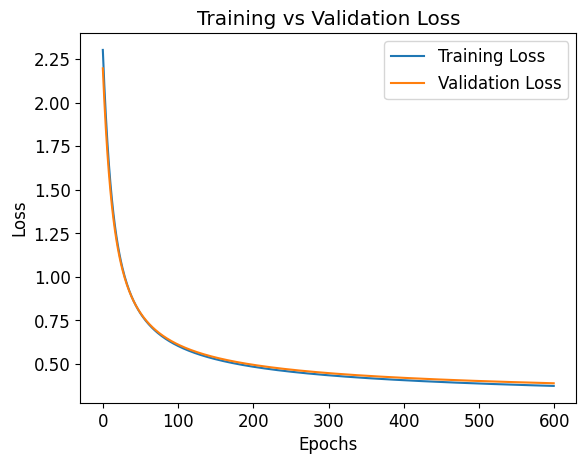

In [12]:
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss") 
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

(b) What do you observe? Is this what you expected?<br>

So from this plot we have the number of epochs on the x axis and the loss on the y axis. We can see that the training (blue) and validation (orange) losses start at around 2.25 and then they start tp drop sharply after the first 50 iterations. This means that the model has learned how to update the model to minimise the error. We can also see that the model is not overfitting the data because both the lines are almost perfectly overlapping each other. It performed almost the same on the unseen validation data. The model maybe underfitting the data after 270 epoch, the model could be trained longer but the model had already found the most stable weights and increasing epoch would just waste computational resources. We knew this at the time of training the model as at each slice of the epochs we could see that the training and validation losses were close to each other and then they reached a mininum where the more number of iterations were not giving any significant improvements in the errors. The smooth lines of the curves also suggest that the chosen learning rate of 0.1 was ideal, if the learning rate was too high, the lines could have bounced around. Overall, the model has fitted the data well.



#### 5.Fit a sklearn.linear model.LogisticRegression model to the data. Do not apply regularisation. Compare the performance of your softmax regression model to the scikit-learn model.

In [13]:

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    multi_class='multinomial',
    solver='lbfgs',
    penalty=None,
    max_iter=600   
)

model.fit(X_train, y_train_main)

y_pred_sklearn = model.predict(X_test)

sklearn_acc = np.mean(y_pred_sklearn == y_test)
print("Sklearn Accuracy:", sklearn_acc)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Sklearn Accuracy: 0.9138095238095238


The code above fits a Logistic Regression from scikit learn. It uses a multinomial setting and no regularisation was applied. The model was fitted on the training data and trained to predict the class labels for the test set. Accuracy was used as a mode of evaluating the model's performance. Although thing to note here was that the number of epochs has to increase from 300 to 1000 as the log

(a) Display a confusion matrix for each model<br>
- Confusion matrix for Numpy model

In [14]:
from sklearn.metrics import confusion_matrix

# NumPy predictions
y_pred_numpy = predict(X_test, W, b)

cm_numpy = confusion_matrix(y_test, y_pred_numpy)

cm_numpy

array([[ 987,    0,    3,    7,    2,   16,    7,    2,   10,    1],
       [   0, 1140,    4,    8,    0,   11,    0,    2,   14,    2],
       [  16,   11,  897,   19,   19,    1,   19,   25,   34,    8],
       [   9,    8,   20,  938,    1,   43,    7,    9,   26,   10],
       [   2,    5,    4,    0,  927,    0,   16,    3,    9,   58],
       [  17,   14,    7,   37,    8,  781,   17,    8,   33,   25],
       [   6,    3,   12,    1,    9,   18,  970,    0,   11,    2],
       [   6,   18,   18,    4,   14,    3,    0,  998,    3,   30],
       [   7,   29,    9,   39,   10,   31,    9,    9,  861,   20],
       [   8,    7,    8,   19,   44,    8,    1,   27,   12,  909]])

We can see from the confusion matrix for the numpy model, that the diagonal line that represents the correct predictions are high, this means that the model was most right in the prediction of labels. Prediction of the label being 1 was correctly predicted 1140 tmes and the least accurate was the label 5 with 781. The most frequent misclassified label was 4 and it was wrongly classified as a 9, 58 times. The next frequent misclassified label was 5 it was classified as an 8 or 3, 39 and 33 times respectively.

- Confusion matrix for sklearn model

In [15]:
cm_sklearn = confusion_matrix(y_test, y_pred_sklearn)
cm_sklearn

array([[ 997,    0,    3,    3,    4,   12,    8,    2,    4,    2],
       [   1, 1140,    6,    8,    0,    8,    0,    2,   13,    3],
       [   7,   10,  940,   20,   13,    5,   14,   12,   21,    7],
       [   6,    5,   25,  940,    3,   46,    4,    9,   26,    7],
       [   3,    5,    9,    6,  928,    0,   12,    9,   11,   41],
       [  11,    4,   10,   34,    5,  823,   15,    4,   31,   10],
       [   9,    3,    8,    0,   14,   16,  976,    0,    5,    1],
       [   6,    2,   12,    9,   11,    0,    1, 1022,    5,   26],
       [   7,   17,   10,   38,    7,   29,   11,    7,  882,   16],
       [   3,    6,    3,   17,   27,    5,    0,   28,    7,  947]])

We can see from the confusion matrix of the sklean logistic model that the accuracy was much better. Label 1 and label 7 was correctly identified 1140 and 1022  times respectively. Label 5 was still the main weak point in the model's prediction as it only classified it 823, but a small increase compared to the numpy model. We can see that the the sklearn model performed slightly better than the numpy model and this holds true due to the accuracy values for each model.

(b) Show appropriate evaluation metrics for both models.


In [16]:
from sklearn.metrics import recall_score, f1_score

# Accuracy for both models
numpy_acc = accuracy(y_test, predict(X_test, W, b))
sklearn_acc = sklearn_acc = np.mean(y_pred_sklearn == y_test)

print("Numpy Accuracy:", round(numpy_acc,4))
print("Sklearn Accuracy:", round(sklearn_acc,4))

# Recall for both models
recall_numpy = recall_score(y_test, y_pred_numpy, average='macro')
recall_sklearn = recall_score(y_test, y_pred_sklearn, average='macro')

print("NumPy Recall:", round(recall_numpy,4))
print("Sklearn Recall:", round(recall_sklearn,4))

# F1 score for both models
f1_numpy = f1_score(y_test, y_pred_numpy, average='macro')
f1_sklearn = f1_score(y_test, y_pred_sklearn, average='macro')

print("NumPy F1 Score:", round(f1_numpy,4))
print("Sklearn F1 Score:", round(f1_sklearn,4))

Numpy Accuracy: 0.896
Sklearn Accuracy: 0.9138
NumPy Recall: 0.8944
Sklearn Recall: 0.9127
NumPy F1 Score: 0.8945
Sklearn F1 Score: 0.9127


- To evaluate and compare the models created, the accuracy, recall and F1 scores for each model was extract and compared. We can see from the outputs that the sklearn model performed better with an accuracy score of 0.9138 compared to the numpy model of 0.896, this means that the sklearn model was able to correctly classify 91.38% of the labels while only 89.60% was correctly classified by the numpy model.<br>
- Recall, which is the measure of the ratio of positive instances that are correctly detected by the classifier, the sklearn model has recall of 0.9127 and the numpy model had 0.8944 which suggests that the sklearn model was better able to correctly classify the labels.<br>
- F1 score or also know as the harmonic mean of precision and recall Whereas the regular mean treats all values equally, the harmonic mean gives much more weight to low values. The sklearn model has an F1 score of 0.9127 and numpy model had 0.8945, which confirms that the sklearn model was the better model amongst the two.

(c) Comment on the results. Are they what you expected? Why or why not?<br><br>
Based on the results as above the results are as expected, the sklearn model outperformed the numpy model on all metrics because the numpy model uses basic gradient decent and a fixed learning rate whereas the sklearn model uses more advanced optimisation algorithm which converges more efficiently and finds better set of parameters. Sklearn model is highly optimised and numerically stable thereby allowing it to achieve slightly higher accuracy, recall and F1 score. The numpy model was more sensitive to the hyperparameters set such as the learning rate and early stopping that will limit its performance. Overall the Sklearn model is the best model as it is more advanced of the two.

6. Comment on how the performance of your softmax regression model compares to the logistic regression model from scikit-learn<br><br>
The numpy model's performance based on the softmax regression was slightly lower than the sklean, accross all model evaluations. Both the models have the same underlying implementation of the softmax algorithm but the main difference is in the optimisation. The numpy model used basic gradient decent and fixed learning rates and early stopping and this would put a limit on how well the model converges to a minimum. The Sklearn model is considered the gold standard as it is optimised with LBFGS (Limited-memory Broyden–Fletcher–Goldfarb–Shanno) which is a numerical optimisation algorithm used to estimate the best weights for a logistic regression model. Which makes it more faster, stable and better at finding the optimal parameters.


###  Part2: Support Vector Machine Regression<br>
#### Introduction<br>
Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression tasks. It tries to find the best boundary known as hyperplane that separates different classes in the data. It is useful when you want to do binary classification like spam vs. not spam or cat vs dog. The key idea behind the SVM algorithm is to find the hyperplane that best separates two classes by maximising the margin between them. This margin is the distance from the hyperplane to the nearest data points (support vectors) on each side.

1.Write a function that can generate a random toy n-degree polynomial dataset of the form,where x∈[−3,3], ak∼U(0,1), andϵ∼N(0,1). Your function should take two arguments: degree,and n samples. Show your function works by plotting some generated datasets.

In [17]:
np.random.seed(42)

def generate_polynomial_data(degree, n_samples):
    # x in [-3, 3]
    x = np.random.uniform(-3, 3, n_samples)

    # coefficients a_k ~ U(0,1)
    a = np.random.uniform(0, 1, degree + 1)

    # compute polynomial
    y = np.zeros(n_samples)
    for k in range(degree + 1):
        y += a[k] * (x ** k)

    # add Gaussian noise ε ~ N(0,1)
    noise = np.random.normal(0, 1, n_samples)
    y = y + noise

    return x, y

In the code above we are creating a numpy function to generate random input values from an uniform range of -3 to 3. Then we create a random coefficients for each polynomial term, where each coefficient is sampled from a uniform range between 0 and 1. y is computed by summing up each polynomial term from 0 up to a specified degree. After computation a noise of the Gaussian type is added and it is drawn from the normal distribution.

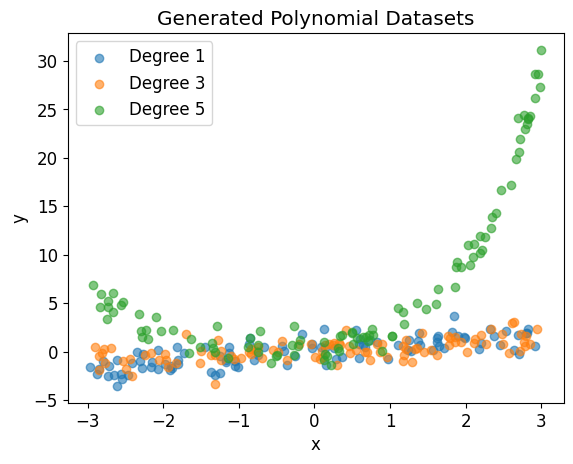

In [18]:
np.random.seed(42)
# Example datasets
degrees = [1, 3, 5]

for d in degrees:
    x, y = generate_polynomial_data(d, 100)

    plt.scatter(x, y, label=f"Degree {d}", alpha=0.6)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Generated Polynomial Datasets")
plt.legend()
plt.show()

From the plot generated we can see that degree 1 represents a linear relationship where y changes at a constant rate relative to x. Degree 3 is a cubic relationship. As x changes and moves away from 0 the changes in why get bigger and move upwards or downwards more quickly than the linear model. The last Degree 5 is a polynomial relationship, as x reaches 2 the values of y move exponentially higher as $x^e$ increases, which means that small changes in x cause massive changes in y.

2.Generate three toy datasets using your function: a linear, a quadratic, and cubic dataset. Use nsamples=1000. Make sure you have a training and testset for each dataset.

In [19]:

x_linear, y_linear = generate_polynomial_data(1, 1000)

# Quadratic (degree = 2)
x_quad, y_quad = generate_polynomial_data(2, 1000)

# Cubic (degree = 3)
x_cubic, y_cubic = generate_polynomial_data(3, 1000)

# reshape x (n_samples, 1)
x_linear = x_linear.reshape(-1, 1)
x_quad = x_quad.reshape(-1, 1)
x_cubic = x_cubic.reshape(-1, 1)
 
# Linear split
X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    x_linear, y_linear, test_size=0.2, random_state=42
)

# Quadratic Split
X_train_quad, X_test_quad, y_train_quad, y_test_quad = train_test_split(
    x_quad, y_quad, test_size=0.2, random_state=42
)

# Cubic Split
X_train_cubic, X_test_cubic, y_train_cubic, y_test_cubic = train_test_split(
    x_cubic, y_cubic, test_size=0.2, random_state=42
)

In the above code we are generating x and y linear,quadratic and cubic data, using degrees 1, 2 and 3 respectively from a sample of 1000. Then we are reshaping the x data for each model to -1 and 1. Currently the data is a 1d array and we rephape it so that the SVM modeled later on can use this 2d data i.e. columns and rows do its calculations otherwise we get an error as SVM's need 2d arrays. After these steps we are splitting each model into training and test sets by a 80/20 split and setting the random state so that our results are reproducable.

3. Experiment with fitting a sklearn.svm.SVR model to each of the three datasets using kernel=’linear’,kernel=’poly’and kernel=’rbf’.

In [20]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
# Store datasets for easy looping
datasets = {
    "Linear": (X_train_linear, X_test_linear, y_train_linear, y_test_linear),
    "Quadratic": (X_train_quad, X_test_quad, y_train_quad, y_test_quad),
    "Cubic": (X_train_cubic, X_test_cubic, y_train_cubic, y_test_cubic)
}

kernels = ["linear", "poly", "rbf"]

results = {}

for name, (X_train, X_test, y_train, y_test) in datasets.items():
    results[name] = {}
    
    for k in kernels:
        model = SVR(kernel=k)
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        
        results[name][k] = mse
        print(name, k, "MSE:", round(mse,4))

Linear linear MSE: 0.9821
Linear poly MSE: 0.9857
Linear rbf MSE: 0.9782
Quadratic linear MSE: 0.9911
Quadratic poly MSE: 1.0786
Quadratic rbf MSE: 1.017
Cubic linear MSE: 13.4988
Cubic poly MSE: 1.222
Cubic rbf MSE: 2.0903


In the above code we are implementing the Support Vector Regression class within the scikit-learn library, used for solving regression problems (predicting continuous numerical values) using the principles of Support Vector Machines (SVM). we are creating a for loop to run through the different models defined and using the 3 kernals i.e. linear, poly and Radial Basis Function (RBF). This would save us time and the code would look more cleaner than having to manually doing it for each step (9 steps). We are then predicting the outcome of y and calculating the Mean Square Error (MSE) to find out how well each model and kernal had performed.

(a) Show plots of the fitted regression function for each kernel and each dataset.

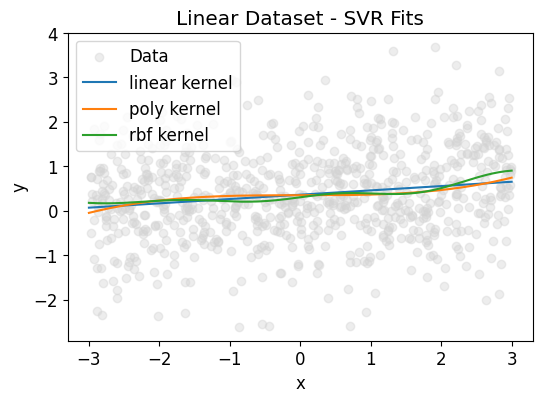

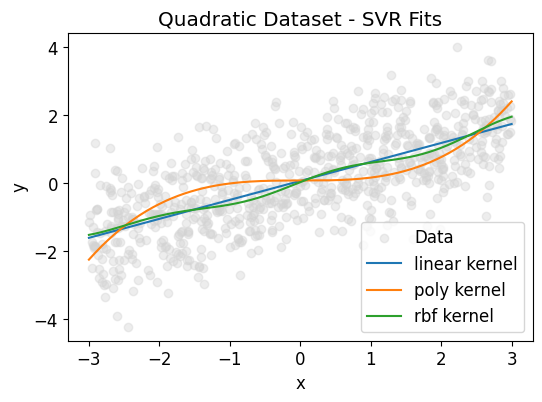

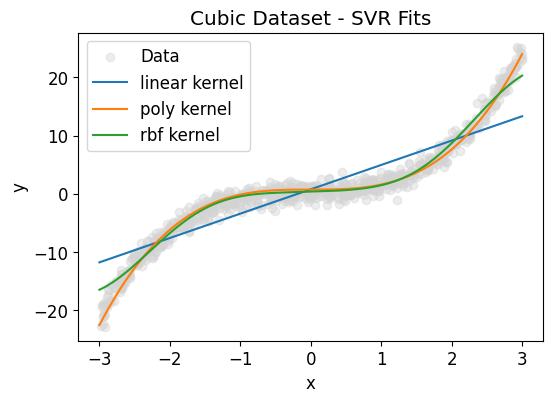

In [21]:
kernels = ["linear", "poly", "rbf"]

datasets = {
    "Linear": (X_train_linear, y_train_linear),
    "Quadratic": (X_train_quad, y_train_quad),
    "Cubic": (X_train_cubic, y_train_cubic)
}

# smooth x for plotting curves
X_plot = np.linspace(-3, 3, 200).reshape(-1, 1)

for name, (X_tr, y_tr) in datasets.items():
    plt.figure(figsize=(6,4))
    
    # scatter training data
    plt.scatter(X_tr, y_tr, alpha=0.4, label="Data",color='lightgrey')
    
    for k in kernels:
        model = SVR(kernel=k)
        model.fit(X_tr, y_tr)
        
        y_plot = model.predict(X_plot)
        plt.plot(X_plot, y_plot, label=f"{k} kernel")
    
    plt.title(f"{name} Dataset - SVR Fits")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend()
    plt.show()

For the plotting of the data we are creating a dictionary for the x_train and y_train for each of the respective models and created scatter plots for each of the dataset with the kernals in different colours for easier identification. 

(b) Comment on the results. Are they what you expected?

We can break this down and explain each of the datasets and the kernals performance

- Linear Dataset<br>
We can see from the plot of the linear dataset, the data follow a straight line trend with noise. The linear kernal (blue) fits the data perfectly as it matches the degree of the data. The rbf (green) and poly (orange) kernals also perform well as they can easily adapt themselves to the linear shape. In this case the linear kernal is the best model. <br><br>
- Quadratic Dataset<br>
From the plot of the quadratic dataset, the data has a "U" shape. The linear kernal fails to adapt to the data, cutting through the data which is basically underfitting. The poly kernal does not perform as well as the rbf kernal as the rbf kernal tracks the data much better.<br><br>
- Cubic Dataset<br>
The cubic dataset data shows an "S" curve and again the linear kernal is too rigid to follow the bends. The poly kernal captures the general trend but struggles with the tails of the data. But the rbf kernal perfect bends along with the data and provides the smoothest and most accurate fit to the data.<br><br>
Expectation:<br>
-  The RBF kernal performs the best because it operates by measuring the similarity between data points based on their Euclidean distance in the input space. It assigns high similarity values to points that are close to each other and lower values to points that are farther apart. This behavior captures the local structure of the data, making the RBF kernel particularly effective in capturing nonlinear relationships.


4. Perform grid-search with k-fold cross-validation (k=5) on atleast three hyperparameters (including kernel) with two different values each ($2^3$ = 8 total combinations) for your cubic dataset.

In [22]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'kernel': ['poly', 'rbf'],   # Model type
    'C': [0.1, 10],               # Regularisation
    'gamma': ['scale', 'auto']   # Sensitivity to the data
}

grid_search = GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    verbose=1
)

grid_search.fit(X_train_cubic, y_train_cubic)  # Fitting 

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", round(grid_search.best_score_,4))

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best Parameters: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}
Best Score: -1.1623


(a) What hyperparameters did you choose? How many models did you fit in total? <br><br>
kernels were poly and rbf, C was 0.1 or 10 and gamma of scale or auto.<br>
The kernel was varied between polynomial and RBF to compare structured and flexible nonlinear models. The regularisation parameter C was set to 0.1 and 10 to explore the trade off between underfitting and overfitting. The gamma parameter was tested using 'scale' and 'auto' to examine different levels of model sensitivity. This combination provides a balanced search across model complexity and flexibility.

(b) Present your results for the optimal hyperparameter combination.

The hyperparameters chosen were, a regularisation of 10 which is a moderate regularisation term, gamma as auto was chosen because the model benefited from a specific sensitivity to the data points and the rbf kernal. And there we 40 models fitted in total. And the best score was -1.1623

5.Given your optimal model found in the previous step, evaluate your model on the testset. Present your results

In [23]:
grid_search.best_params_
grid_search.best_estimator_

y_pred = grid_search.best_estimator_.predict(X_test_cubic)
mse = np.mean((y_test_cubic - y_pred)**2)

print("Test MSE:", round(mse,4))

Test MSE: 1.1701


The final model achieved a test mean squared error (MSE) of 1.1701, which is slightly higher than the cross-validation error (1.1623). This indicates good generalisation performance, as the model performs similarly on unseen data while avoiding significant overfitting. The small increase in test error compared to validation error suggests that the model selection process was effective and did not overfit to the validation data.